# <font color='red'>Clustering Assignment</font>

**There will be some functions that start with the word "grader" ex: grader_actors(), grader_movies(), grader_cost1() etc, you should not change those function definition.<br><br>Every Grader function has to return True.**

**Please check [clustering assignment helper functions](https://drive.google.com/file/d/1V29KhKo3YnckMX32treEgdtH5r90DIjU/view?usp=sharing) notebook before attempting this assignment.**

*  Read graph from the given <font color='blue'>movie_actor_network.csv</font> (note that the graph is bipartite graph.)

*  Using stellergaph and gensim packages, get the dense representation(128dimensional vector) of every node in the graph. [Refer <font color='blue'>Clustering_Assignment_Reference.ipynb</font>]

* Split the dense representation into actor nodes, movies nodes.(Write you code in <font color='blue'>def data_split()</font>)


# <font color='red'>Task 1 : Apply clustering algorithm to group similar actors</font>

 1. For this task consider only the actor nodes 
 2. Apply any clustering algorithm of your choice <br>
    Refer : https://scikit-learn.org/stable/modules/clustering.html
 3. Choose the number of clusters for which you have maximum score of <b>$Cost1*Cost2$</b><br>
 4. Cost1 = $\frac{1}{N}\sum_{\text{each cluster i}}  \frac{\text{(number of nodes in the largest connected component in the graph with the actor nodes and its movie neighbours in cluster i)}}{\text{(total number of nodes in that cluster i)}}$ where N= number of clusters 
<br> (Write your code in <font color='blue'>def cost1()</font>)<br>
 5. Cost2 = $\frac{1}{N}\sum_{\text{each cluster i}}  \frac{\text{(sum of degress of actor nodes in the graph with the actor nodes and its movie neighbours in cluster i)}}{\text{(number of unique movie nodes in the graph with the actor nodes and its movie neighbours in cluster i)}}$ where N= number of clusters 
 <br> (Write your code in <font color='blue'>def cost2()</font>)<br>
 6. Fit the clustering algorithm with the opimal number_of_clusters and get the cluster number for each node <br>
 7. Convert the d-dimensional dense vectors of nodes into 2-dimensional using dimensionality reduction techniques (preferably TSNE)<br>
 8. Plot the 2d scatter plot, with the node vectors after step e and give colors to nodes such that same cluster nodes will have same color

<img src='https://i.imgur.com/4SPYPFa.jpg'>

# <font color='red'>Task 2 : Apply clustering algorithm to group similar movies</font>


1. For this task consider only the movie nodes
2. Apply any clustering algorithm of your choice
3.Choose the number of clusters for which you have maximum score of $Cost1*Cost2$ <br>

    Cost1 = $\frac{1}{N}\sum_{\text{each cluster i}}  \frac{\text{(number of nodes in the largest connected component in the graph with the movie nodes and its actor neighbours in cluster i)}}{\text{(total number of nodes in that cluster i)}}$ where N= number of clusters <br>
(Write your code in <font color='blue'>def cost1()</font>)<br>
	
4. Cost2 = $\frac{1}{N}\sum_{\text{each cluster i}}  \frac{\text{(sum of degress of movie nodes in the graph with the movie nodes and its actor neighbours in cluster i)}}{\text{(number of unique actor nodes in the graph with the movie nodes and its actor neighbours in cluster i)}}$ 
where N= number of clusters 
<br>(Write your code in <font color='blue'>def cost2()</font>)<br>


**Algorithm for actor nodes**

<pre>
	for number_of_clusters in [3, 5, 10, 30, 50, 100, 200, 500]:
		algo = clustering_algorith(clusters=number_of_clusters)
        # you will be passing a matrix of size N*d where N number of actor nodes and d is dimension from gensim
		algo.fit(the dense vectors of actor nodes) 
        You can get the labels for corresponding actor nodes (algo.labels_)
        Create a graph for every cluster(ie., if n_clusters=3, create 3 graphs)
        (You can use ego_graph to create subgraph from the actual graph)
        compute cost1,cost2 
           (if n_cluster=3, cost1=cost1(graph1)+cost1(graph2)+cost1(graph3) # here we are doing summation
            cost2=cost2(graph1)+cost2(graph2)+cost2(graph3)
		computer the metric Cost = Cost1*Cost2
	return number_of_clusters which have maximum Cost
	</pre>

<br>

In [2]:
!pip install networkx==2.3

^C


In [74]:
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
# you need to have tensorflow 
from stellargraph.data import UniformRandomMetaPathWalk
from stellargraph import StellarGraph

In [75]:
data=pd.read_csv('movie_actor_network.csv', index_col=False, names=['movie','actor'])

In [76]:
edges = [tuple(x) for x in data.values.tolist()]

In [77]:
B = nx.Graph()
B.add_nodes_from(data['movie'].unique(), bipartite=0, label='movie')
B.add_nodes_from(data['actor'].unique(), bipartite=1, label='actor')
B.add_edges_from(edges, label='acted')

In [78]:
A = list(nx.connected_component_subgraphs(B))[0]

In [79]:
print("number of nodes", A.number_of_nodes())
print("number of edges", A.number_of_edges())

number of nodes 4703
number of edges 9650


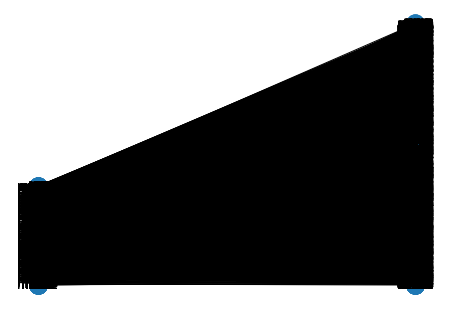

In [80]:
l, r = nx.bipartite.sets(A)
pos = {}

pos.update((node, (1, index)) for index, node in enumerate(l))
pos.update((node, (2, index)) for index, node in enumerate(r))
  
nx.draw(A, pos=pos, with_labels=True)
plt.show()

In [81]:
movies = []
actors = []
for i in A.nodes():
    if 'm' in i:
        movies.append(i)
    if 'a' in i:
        actors.append(i)
print('number of movies ', len(movies))
print('number of actors ', len(actors))

number of movies  1292
number of actors  3411


In [82]:

# Create the random walker
rw = UniformRandomMetaPathWalk(StellarGraph(A))

# specify the metapath schemas as a list of lists of node types.
metapaths = [
    ["movie", "actor", "movie"],
    ["actor", "movie", "actor"]
]

walks = rw.run(nodes=list(A.nodes()), # root nodes
               length=100,  # maximum length of a random walk
               n=1,        # number of random walks per root node 
               metapaths=metapaths
              )

print("Number of random walks: {}".format(len(walks)))

Number of random walks: 4703


In [83]:
from gensim.models import Word2Vec
model = Word2Vec(walks, size=128, window=5)

In [84]:
model.wv.vectors.shape  # 128-dimensional vector for each node in the graph

(4703, 128)

In [85]:
# Retrieve node embeddings and corresponding subjects
node_ids = model.wv.index2word  # list of node IDs
node_embeddings = model.wv.vectors  # numpy.ndarray of size number of nodes times embeddings dimensionality
node_targets = [ A.node[node_id]['label'] for node_id in node_ids]

In [86]:
#print(len(node_ids),len(node_embeddings),len(node_targets))
#node_ids.find('a1')

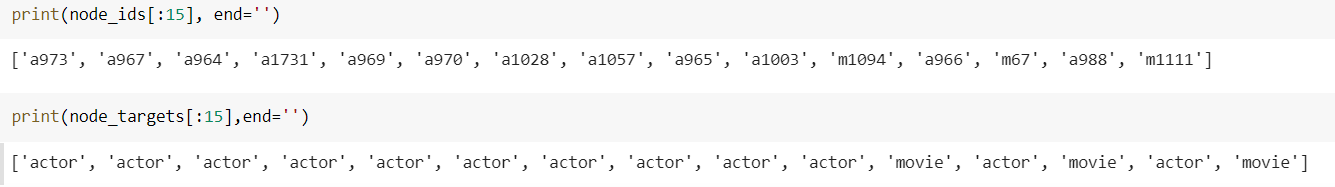

In [87]:
def data_split(node_ids,node_targets,node_embeddings):
    '''In this function, we will split the node embeddings into actor_embeddings , movie_embeddings '''
    actor_nodes,movie_nodes=[],[]
    actor_embeddings,movie_embeddings=[],[]
    for value in node_ids:
        if 'a' in value:
            actor_nodes.append(value)
        if 'm' in value:
            movie_nodes.append(value)
    for value in actor_nodes:
        index_value = node_ids.index(value)
        actor_embeddings.append(node_embeddings[index_value])
    for value in movie_nodes:
        index_value = node_ids.index(value)
        movie_embeddings.append(node_embeddings[index_value])    
      
    # split the node_embeddings into actor_embeddings,movie_embeddings based on node_ids
    # By using node_embedding and node_targets, we can extract actor_embedding and movie embedding
    # By using node_ids and node_targets, we can extract actor_nodes and movie nodes
    #print(len(movie_nodes))
    return actor_nodes,movie_nodes,actor_embeddings,movie_embeddings
actor_nodes,movie_nodes,actor_embeddings,movie_embeddings=data_split(node_ids,node_targets,node_embeddings)

<font color='cyan'>Graded function - 1</font>

In [88]:
def grader_actors(data):
    assert(len(data)==3411)
    return True
grader_actors(actor_nodes)

True

<font color='cyan'>Graded function - 2</font>

In [89]:
def grader_movies(data):
    assert(len(data)==1292)
    return True
grader_movies(movie_nodes)

True

<font color='blue'>Calculating cost1</font>

Cost1 = $\frac{1}{N}\sum_{\text{each cluster i}}  \frac{\text{(number of nodes in the largest connected component in the graph with the actor nodes and its movie neighbours in cluster i)}}{\text{(total number of nodes in that cluster i)}}$ where N= number of clusters <br><br>
<br>

In [90]:
def cost1(graph,number_of_clusters):
    '''In this function, we will calculate cost1'''
    
    #value = list(graph.degree)
    connected_node_list = list(nx.connected_components(graph))
    #print(connected_node_list,"connected list")
    value = max(connected_node_list,key=len)
    sorted_value=sorted(value,key=lambda x: x[1], reverse=True)
    node_list =list(graph.nodes)
    
    cost1 = (1/number_of_clusters)*((len(value))/len(node_list))

    return cost1
#cost1(graded_graph_1,3)
#nx.connected_components(graded_graph_1)

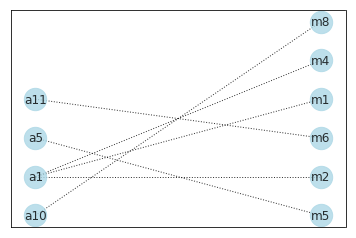

In [91]:
import networkx as nx
from networkx.algorithms import bipartite
graded_graph= nx.Graph()
graded_graph.add_nodes_from(['a1','a5','a10','a11'], bipartite=0) # Add the node attribute "bipartite"
graded_graph.add_nodes_from(['m1','m2','m4','m6','m5','m8'], bipartite=1)
graded_graph.add_edges_from([('a1','m1'),('a1','m2'),('a1','m4'),('a11','m6'),('a5','m5'),('a10','m8')])
l={'a1','a5','a10','a11'};r={'m1','m2','m4','m6','m5','m8'}
pos = {}
pos.update((node, (1, index)) for index, node in enumerate(l))
pos.update((node, (2, index)) for index, node in enumerate(r))
nx.draw_networkx(graded_graph, pos=pos, with_labels=True,node_color='lightblue',alpha=0.8,style='dotted',node_size=500)
#nx.draw_networkx(graded_graph)

<font color='cyan'>Graded function - 3</font>

In [92]:
graded_cost1=cost1(graded_graph,3)
def grader_cost1(data):
    assert(data==((1/3)*(4/10))) # 1/3 is number of clusters
    return True
grader_cost1(graded_cost1)

True

<font color='blue'>Calculating cost2</font>

Cost2 = $\frac{1}{N}\sum_{\text{each cluster i}}  \frac{\text{(sum of degress of actor nodes in the graph with the actor nodes and its movie neighbours in cluster i)}}{\text{(number of unique movie nodes in the graph with the actor nodes and its movie neighbours in cluster i)}}$ where N= number of clusters 

In [93]:
def cost2(graph,number_of_clusters):
    '''In this function, we will calculate cost1'''
    sum_degree=graph.degree(actor_nodes)
    sum_deg=sum([lis[1] for lis in sum_degree])
    unique_movie=graph.nodes()-actor_nodes 
    cost2=(sum_deg/len(unique_movie))/number_of_clusters   
    
    return cost2

<font color='cyan'>Graded function - 4</font>

In [94]:
graded_cost2=cost2(graded_graph,3)
def grader_cost2(data):
    assert(data==((1/3)*(6/6))) # 1/3 is number of clusters
    return True
grader_cost2(graded_cost2)

True

<font color='blue'>Grouping similar actors</font>

In [95]:
import math
#print(math.floor(len(actor_nodes)/5))
edge_list =list(A.edges)


In [98]:
from sklearn.cluster import KMeans
import numpy
#cluster_list = [3, 5, 10, 30, 50, 100, 200, 500]
def optimal_cluster(cluster_list,actor_nodes,edge_list):
    print(cluster_list)
    #cluster_list = [3]
    cots1_and_cost2 = []
    cost_one_plus_two = []
    for c_value in cluster_list:

        #list_of_actor_node_chunk = [actor_nodes[i:i + math.ceil(len(actor_nodes)/c_value)] for i in range(0, len(actor_nodes), math.ceil(len(actor_nodes)/c_value))]
        np_list_of_actor_node_chunk = np.array_split(actor_nodes,c_value)
        list_of_actor_node_chunk = []
        for value in np_list_of_actor_node_chunk:
            list_of_actor_node_chunk.append(value.tolist())
        #print(len(list_of_actor_node_chunk),"length of the cluster")
        cost_one_list = []
        cost_two_list = []

        for val in list_of_actor_node_chunk:
            #print(len(val))
            cor_edge = []
            cor_master_node = []
            for index,value in enumerate(val):
                if index==0:
                    cor_edge = [item for item in edge_list if item[1] == value]
                    #print(cor_edge,"core edge")
                else:
                    cor_edge.extend([item for item in edge_list if item[1] == value])
            for value in cor_edge:
                cor_master_node.append(value[0])
            cor_master_node = list(set(cor_master_node))
            sub_graph= nx.Graph()
            sub_graph.add_nodes_from(val, bipartite=0) # Add the node attribute "bipartite"
            sub_graph.add_nodes_from(cor_master_node, bipartite=1)
            sub_graph.add_edges_from(cor_edge)
            left=set(val);right=set(cor_master_node)
            pos = {}
            pos.update((node, (1, index)) for index, node in enumerate(left))
            pos.update((node, (2, index)) for index, node in enumerate(right))
            cost_one = cost1(sub_graph,c_value)
            cost_two = cost2(sub_graph,c_value)
            cost_one_list.append(cost_one)
            cost_two_list.append(cost_two)
        cost_one_plus_two.append(sum(cost_one_list)*sum(cost_two_list))
        #print(cost_one_plus_two,"cost_one*cost_two")
        #print(cost_one_plus_two.index(max(cost_one_plus_two)))
    return cost_one_plus_two.index(max(cost_one_plus_two)),cost_one_plus_two        

In [99]:
cluster_list = [3, 5, 10, 30, 50, 100, 200,500]
optimal_cluster_index,metric_list_actor = optimal_cluster(cluster_list,actor_nodes,edge_list)

[3, 5, 10, 30, 50, 100, 200, 500]


In [100]:
print(metric_list_actor)

[1.2472385640287507, 0.8206631238829448, 0.4264488492371019, 0.1857486744309668, 0.14127753215277083, 0.11677580733807778, 0.1281928938932591, 0.21292761745008124]


<font color='blue'>Displaying similar actor clusters</font>

In [101]:
from sklearn.manifold import TSNE
transform = TSNE #PCA

trans_actor = transform(n_components=2)
actor_embeddings_2d = trans_actor.fit_transform(actor_embeddings)


#y_pred = KMeans(n_clusters=3).fit_predict(actor_embeddings)


In [102]:
y_pred = KMeans(n_clusters=cluster_list[optimal_cluster_index])

In [103]:
#actor_embeddings_2d[:,2]
y_pred.fit(actor_embeddings_2d)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

Text(0.5,1,'Anisotropicly Distributed Blobs')

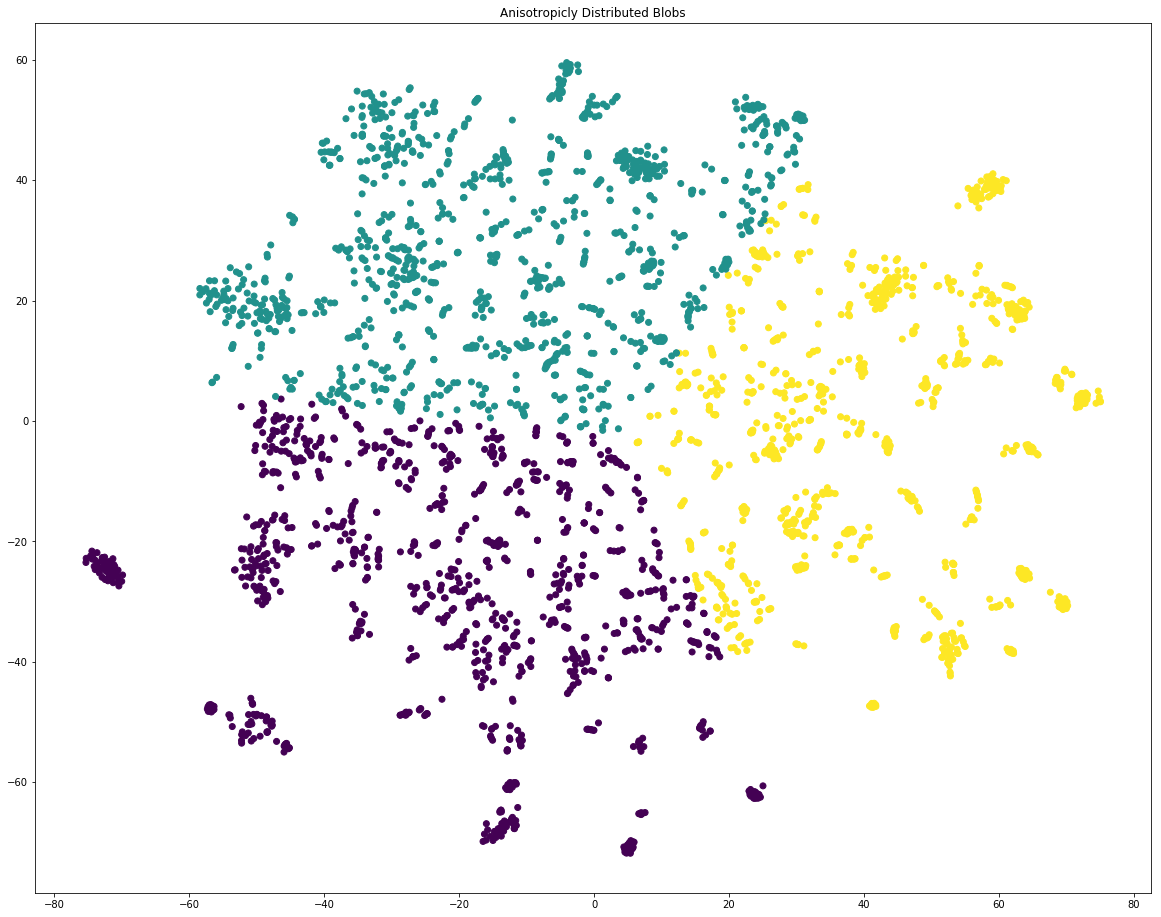

In [104]:

#plt.subplot(222)
plt.figure(figsize=(20,16))
plt.scatter(actor_embeddings_2d[:,0],actor_embeddings_2d[:,1], c=y_pred.labels_)
plt.title("Anisotropicly Distributed Blobs")

<font color='blue'>Grouping similar movies</font>

In [107]:
from sklearn.cluster import KMeans
import numpy
#cluster_list = [3, 5, 10, 30, 50, 100, 200, 500]
def optimal_cluster(cluster_list,movie_nodes,edge_list):
    #print(cluster_list)
    #cluster_list = [3]
    cots1_and_cost2 = []
    cost_one_plus_two = []
    for c_value in cluster_list:

        #list_of_actor_node_chunk = [actor_nodes[i:i + math.ceil(len(actor_nodes)/c_value)] for i in range(0, len(actor_nodes), math.ceil(len(actor_nodes)/c_value))]
        np_list_of_movie_node_chunk = np.array_split(movie_nodes,c_value)
        list_of_movie_node_chunk = []
        for value in np_list_of_movie_node_chunk:
            list_of_movie_node_chunk.append(value.tolist())
        #print(len(list_of_movie_node_chunk),"length of the cluster")
        cost_one_list = []
        cost_two_list = []

        for val in list_of_movie_node_chunk:
            #print(len(val))
            cor_edge = []
            cor_actor_node = []
            for index,value in enumerate(val):
                if index==0:
                    cor_edge = [item for item in edge_list if item[0] == value]
                    #print(cor_edge,"core edge")
                else:
                    cor_edge.extend([item for item in edge_list if item[0] == value])
            for value in cor_edge:
                cor_actor_node.append(value[1])
            cor_actor_node = list(set(cor_actor_node))
            #print(len(list(set(cor_edge))),"no of edge")
            #print(len(cor_actor_node),"no of actor node")
            #print(cor_edge,"cor_edge")
            #print(cor_master_node,"cor_master_node")
            sub_graph= nx.Graph()
            sub_graph.add_nodes_from(val, bipartite=0) # Add the node attribute "bipartite"
            sub_graph.add_nodes_from(cor_actor_node, bipartite=1)
            sub_graph.add_edges_from(cor_edge)
            left=set(val);right=set(cor_actor_node)
            #print(l,r)
            pos = {}
            pos.update((node, (1, index)) for index, node in enumerate(left))
            pos.update((node, (2, index)) for index, node in enumerate(right))
            cost_one = cost1(sub_graph,c_value)
            cost_two = cost2(sub_graph,c_value)
            #print(cost_one,"costone")
            #print(cost_two,"costwo")
            cost_one_list.append(cost_one)
            cost_two_list.append(cost_two)
        cost_one_plus_two.append(sum(cost_one_list)*sum(cost_two_list))
    return cost_one_plus_two.index(max(cost_one_plus_two)),cost_one_plus_two


In [108]:
cluster_list = [3, 5, 10, 30, 50, 100, 200,500]
optimal_cluster_index,metric_list_movie = optimal_cluster(cluster_list,movie_nodes,edge_list)

In [109]:
print(metric_list_movie)

[6.937606056460235, 6.669620062324362, 6.259728371727215, 5.131383869055477, 4.590469105741213, 3.777756635063676, 3.3154422023163903, 3.873332464010698]


<font color='blue'>Displaying similar movie clusters</font>

In [110]:
trans_movie = transform(n_components=2)
movie_embeddings_2d = trans_movie.fit_transform(movie_embeddings)



In [111]:
y_pred_movie = KMeans(n_clusters=cluster_list[optimal_cluster_index])
#.fit_predict(movie_embeddings_2d)
#label_val = y_pred_movie.
y_pred_movie.fit(movie_embeddings_2d)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [112]:
label_movie = y_pred_movie.labels_

Text(0.5,1,'Anisotropicly Distributed Blobs')

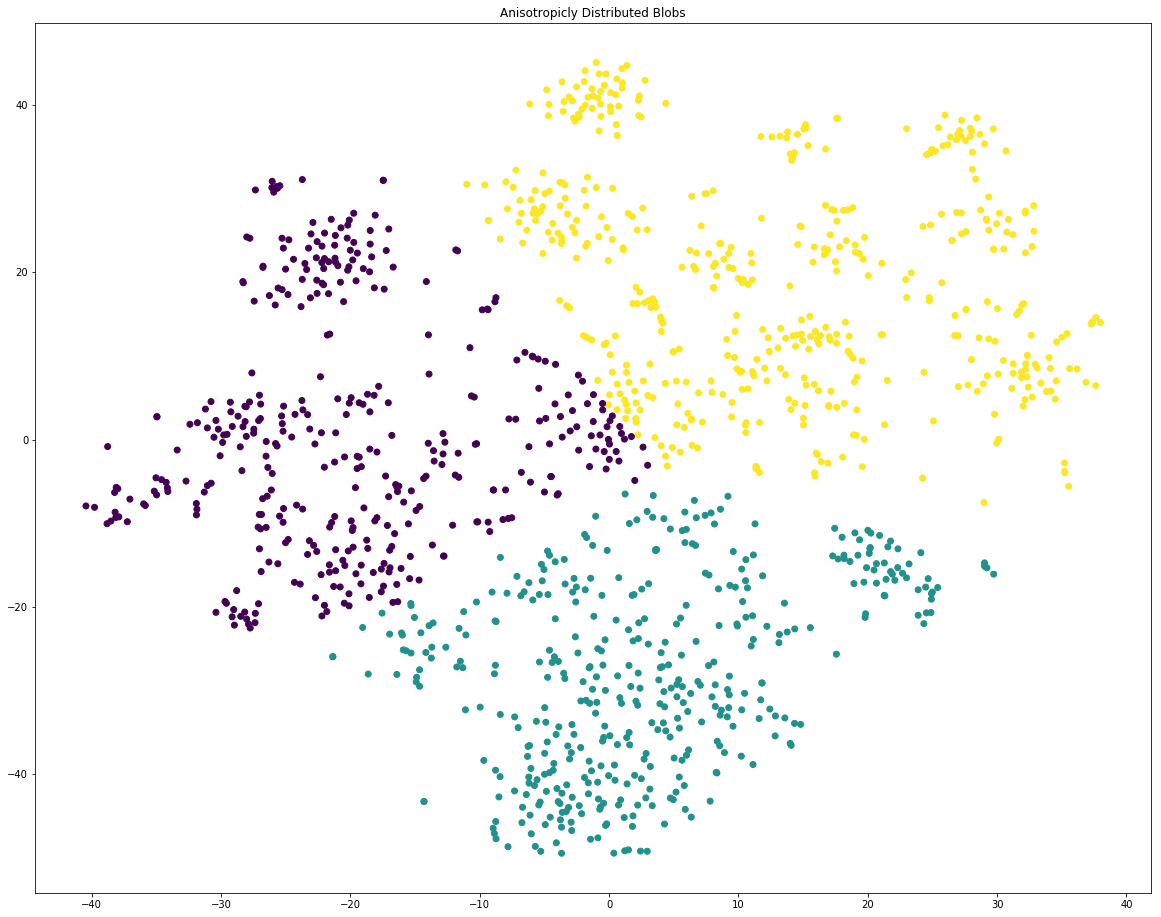

In [113]:
plt.figure(figsize=(20,16))
plt.scatter(movie_embeddings_2d[:,0],movie_embeddings_2d[:,1], c=label_movie)
plt.title("Anisotropicly Distributed Blobs")